In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("muted")

In [3]:
df = pd.read_csv('../data/watches.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (284491, 14)


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284491 entries, 0 to 284490
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  284491 non-null  int64 
 1   name        211906 non-null  object
 2   price       284085 non-null  object
 3   brand       284360 non-null  object
 4   model       254025 non-null  object
 5   ref         241339 non-null  object
 6   mvmt        87806 non-null   object
 7   casem       120220 non-null  object
 8   bracem      109595 non-null  object
 9   yop         284357 non-null  object
 10  cond        208504 non-null  object
 11  sex         188686 non-null  object
 12  size        260894 non-null  object
 13  condition   71569 non-null   object
dtypes: int64(1), object(13)
memory usage: 30.4+ MB


,Unnamed: 0
count,284491.000000
mean,16027.513369
std,17410.945197
min,0.000000
25%,4199.000000
50%,9211.000000
75%,20556.000000
max,72584.000000


In [5]:
df.isnull().sum()

Unnamed: 0         0
name           72585
price            406
brand            131
model          30466
ref            43152
mvmt          196685
casem         164271
bracem        174896
yop              134
cond           75987
sex            95805
size           23597
condition     212922
dtype: int64

**Data completeness note:** Movement type (mvmt) is missing for 
69% of listings, and case material (casem) for 58%. The analyses 
below on these columns reflect the subset of listings where data 
was provided, likely skewing toward more thoroughly documented, 
higher-value watches.

In [6]:
df = df.drop(columns=['Unnamed: 0'])
df['price'] = df['price'].astype(str).str.replace('$', '')
df['price'] = df['price'].str.replace(',', '')

df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(df['price'].dtype)
df[['name', 'price']].head()

df['yop'] = pd.to_numeric(df['yop'], errors='coerce')
print(df['yop'].dtype)
print(df['yop'].isnull().sum())

float64
float64
136575


In [7]:
top_ten_brands = df['brand'].value_counts().head(10)

## Which brands dominate the luxury watch resale market?

The brand distribution tells us where supply concentrates. 
If one or two brands dominate listings, that suggests stronger 
resale demand and liquidity in those brands, relevant for 
understanding what the market actually trades.


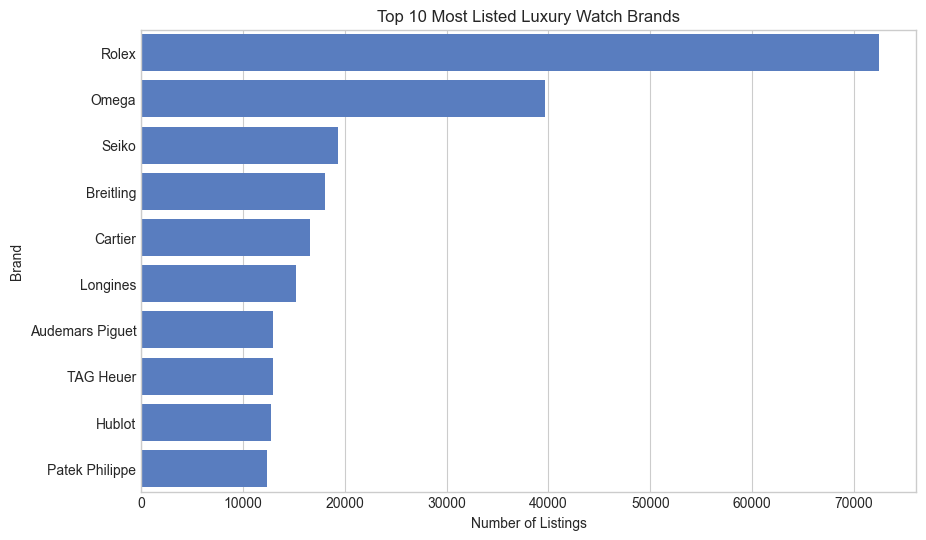

In [8]:
sns.barplot(x=top_ten_brands.values, y=top_ten_brands.index)
plt.title('Top 10 Most Listed Luxury Watch Brands')
plt.xlabel('Number of Listings')
plt.ylabel('Brand')
plt.show()

Rolex dominates by a large margin, followed by Omega and Seiko. 
This reflects their secondary market strength, Rolex in particular 
is known for holding and appreciating in value, which likely drives 
more listings as sellers capitalise on that.

## Does movement type affect price?

Automatic, manual, and quartz movements represent different levels 
of craft and prestige. Automatic movements are generally considered 
more desirable in the luxury segment. This plot tests whether that 
preference shows up in actual resale prices.

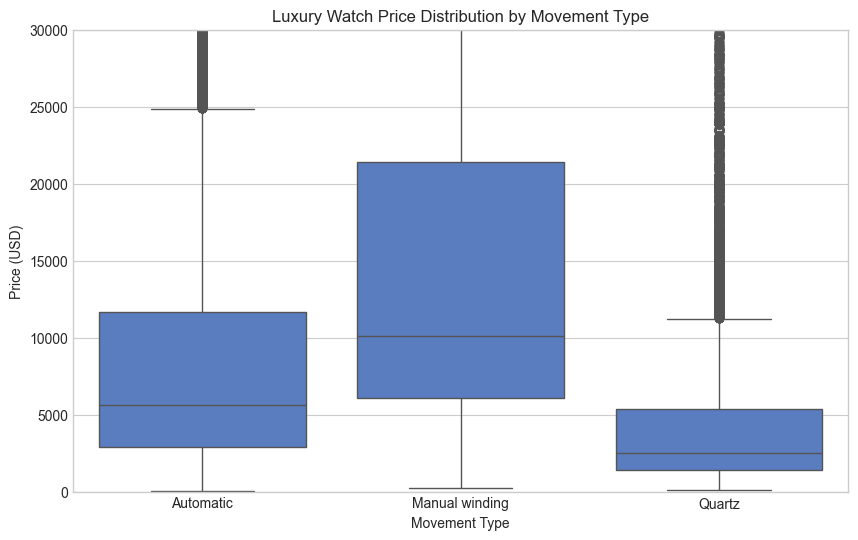

In [9]:
sns.boxplot(data=df, x='mvmt', y='price')
plt.ylim(0, 30000)

plt.title('Luxury Watch Price Distribution by Movement Type')
plt.xlabel('Movement Type')
plt.ylabel('Price (USD)')

plt.show()

Manual winding movements actually show the highest median price 
(~$10,000), ahead of automatic (~$5,500). This likely reflects 
that manual movements are common in high-horology dress watches 
and vintage pieces from prestige manufacturers, manual winding 
there is a heritage choice, not a budget constraint. Quartz shows 
the lowest median by a wide margin, consistent with quartz typically 
being the more accessible tier even within luxury brands.

## How have luxury watch prices changed over time?

The resale market for luxury watches has attracted significant 
speculative interest, particularly post-2020. This plot tracks 
median listing price by year of production to see whether newer 
watches command premiums or whether vintage pieces hold their value.

In [10]:
df['yop'].max()

np.float64(2024.0)

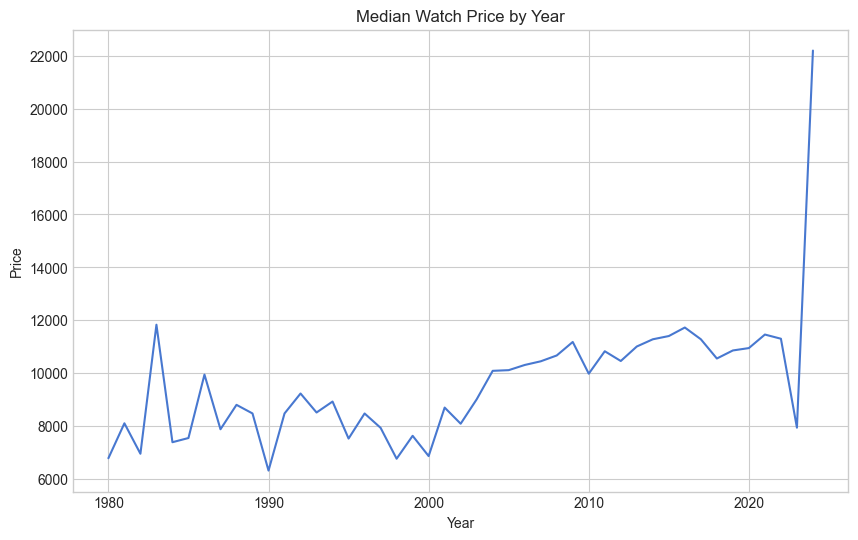

In [11]:
filtered_df = df[(df['yop'] >= 1980) & (df['yop'] <= 2026)]
sns.lineplot(data=filtered_df.groupby('yop')['price'].median().reset_index(), x='yop', y='price')
plt.title("Median Watch Price by Year")
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()


Median price rises steadily from the early 2000s through 2022, 
tracking broader demand growth for luxury watches as alternative 
assets. The sharp dip to ~$8,000 in 2023 followed by a spike above 
$22,000 in 2024 should not be read as a real market signal without 
first checking how many listings exist for those years, at the 
most recent end of the range, sample sizes are likely small enough 
that a handful of listings can swing the median sharply.

In [12]:
filtered_df['yop'].value_counts().sort_index().tail(5)

yop
2020.0     5573
2021.0    10501
2022.0    20654
2023.0    49227
2024.0        1
Name: count, dtype: int64

## How much does condition affect resale price?

Condition is one of the most controllable variables in watch resale. 
Understanding the price premium between Unworn, New, Good, and Fair 
condition gives buyers and sellers a benchmark for condition-based 
valuation.

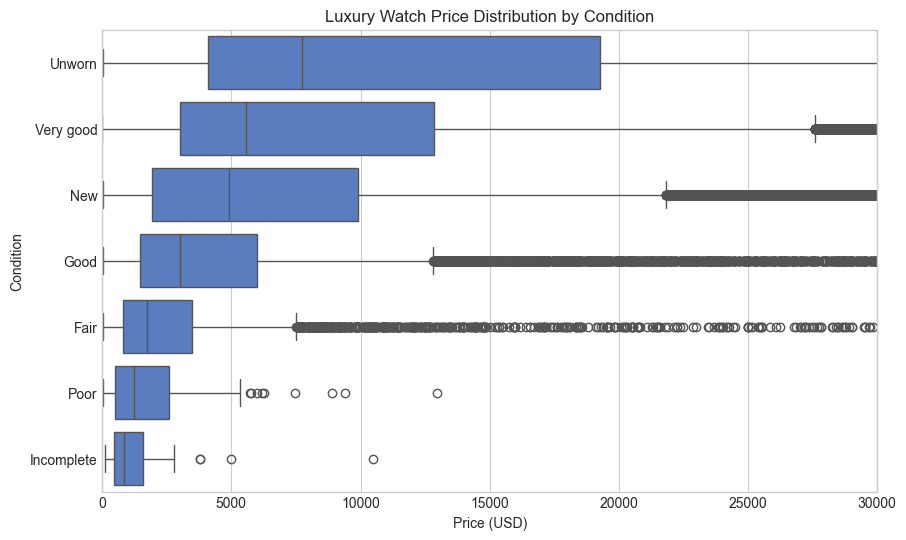

In [13]:
sns.boxplot(data=df, x='price', y='cond')

plt.xlim(0, 30000)

plt.title('Luxury Watch Price Distribution by Condition')
plt.xlabel('Price (USD)')
plt.ylabel('Condition')

plt.show()

Unworn watches command the highest median price, as expected. 
But Very Good condition watches show a higher median price than 
those labelled New, which is counterintuitive. One possible 
explanation: "condition" and "model/brand" are likely correlated 
in this dataset, a Very Good vintage Rolex may still outprice 
a New entry-level brand watch, suggesting the underlying watch 
itself drives price more than condition grade alone. This 
ordering also reverses for the lower conditions: Good, Fair, 
Poor, and Incomplete decline in price roughly as expected, 
suggesting the relationship between condition and price isn't 
linear across the full range.

All condition categories except Poor and Incomplete show extensive 
high-price outliers extending to the dataset's likely true maximum 
(capped here at $30,000 for readability), meaning condition grade 
alone is a weak predictor of price without knowing the brand and model.

In [14]:
df['casem'].value_counts().head(5)

casem
Steel          75793
Gold/Steel     11031
Rose gold       9320
Yellow gold     7875
Titanium        5188
Name: count, dtype: int64

## Does case material drive price differences?

Steel, gold, rose gold, and titanium represent very different 
material costs and market perceptions. This analysis tests whether 
the case material alone is predictive of listing price within the 
top five most common materials.

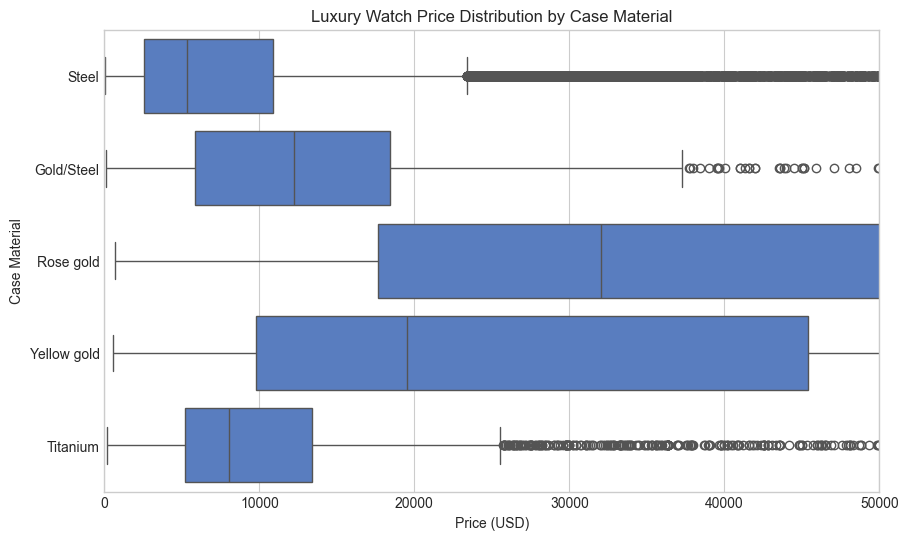

In [15]:
top_materials = df['casem'].value_counts().head(5).index

filtered_materials_df = df[df['casem'].isin(top_materials)]

sns.boxplot(
    data=filtered_materials_df, 
    x='price', 
    y='casem', 
    order=top_materials
)

plt.xlim(0, 50000)

plt.title('Luxury Watch Price Distribution by Case Material')
plt.xlabel('Price (USD)')
plt.ylabel('Case Material')

plt.show()

Rose gold commands the highest median price (~$32,000), even ahead 
of yellow gold (~$19,000), likely reflecting current market fashion, 
as rose gold has been the most sought-after gold tone in recent 
watch resale. Gold/Steel sits in the middle (~$12,000). Titanium, 
despite being a premium material, shows a lower median (~$8,000) 
than any gold variant, suggesting price here tracks precious metal 
content and prestige association more than material cost alone. 
Steel remains both the lowest-priced and highest-volume category, the standard, most accessible luxury material.

## Key Takeaways

- Rolex dominates the resale market by a wide margin, consistent 
  with its reputation for holding and appreciating value.
- Manual winding movements command higher prices than automatic, 
  reflecting their association with high-horology heritage pieces.
- Median prices show a steady rise from 2000-2022, though the most 
  recent years reflect small sample sizes rather than a real trend.
- Condition is a weaker price predictor than expected, Very Good 
  watches outprice New ones, suggesting brand and model dominate 
  over condition grade.
- Rose gold commands the highest prices of any case material, 
  ahead of yellow gold, reflecting current market fashion rather 
  than raw material cost alone.